In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [59]:
path = 'ex1data2.txt'
data = pd.read_csv(path, header=None, names=['Size', 'Bedrooms', 'Price'])
data.head()

,Size,Bedrooms,Price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [60]:
mean = data.mean()
std = data.std()
data = data - mean
data = data / std
data.head()



,Size,Bedrooms,Price
0,0.130010,-0.223675,0.475747
1,-0.504190,-0.223675,-0.084074
2,0.502476,-0.223675,0.228626
3,-0.735723,-1.537767,-0.867025
4,1.257476,1.090417,1.595389


In [61]:
data.insert(0, 'One', 1)
data.head()

,One,Size,Bedrooms,Price
0,1,0.130010,-0.223675,0.475747
1,1,-0.504190,-0.223675,-0.084074
2,1,0.502476,-0.223675,0.228626
3,1,-0.735723,-1.537767,-0.867025
4,1,1.257476,1.090417,1.595389


In [62]:
def cost(x, y, theta):
    delta = x * theta.T
    delta = delta - y
    delta = np.power(delta, 2)
    value = np.sum(delta)
    length = len(x) * 2
    value = value / length
    return value


def descent(x, y, theta, alpha, itr):
    paraCount = theta.shape[1]
    c = np.zeros(itr)
    for i in range(itr):
        temp = np.matrix(np.zeros(paraCount))
        for j in range(paraCount):
            delta = x * theta.T
            delta = delta - y
            delta = np.multiply(delta, x[:, j])
            value = np.sum(delta)
            length = len(x)
            value = alpha * value / length
            temp[0, j] = theta[0, j] - value
        theta = temp
        c[i] = cost(x, y, theta)
    return theta, c


cols = data.shape[1]
x = np.matrix(data.iloc[:, 0:cols - 1].values)
y = np.matrix(data.iloc[:, cols - 1:cols].values)

theta = np.matrix(np.zeros(cols - 1))
alpha = 0.01
itr = 1000
res, c = descent(x, y, theta, alpha, itr)

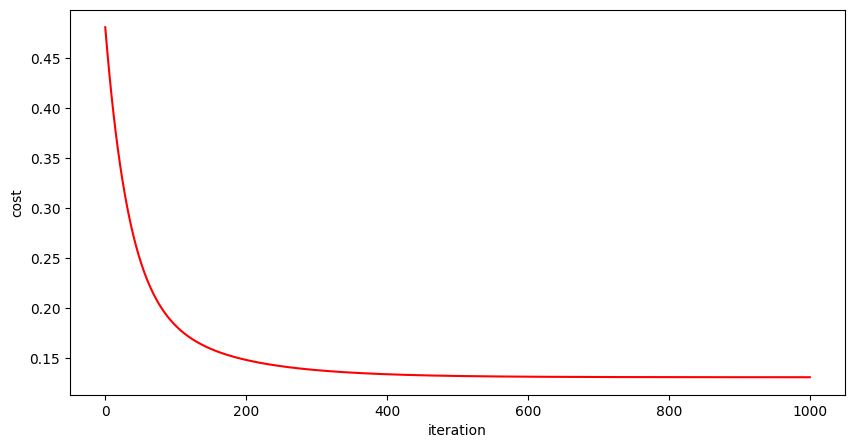

In [63]:
plt.subplots(figsize=(10, 5))

xAxis = np.linspace(0, 1000, 1000)
# xAxis2 = np.arange(0, itr, 1)
plt.plot(xAxis, c, 'red')
plt.xlabel('iteration')
plt.ylabel('cost')
plt.show()

线性回归工具函数

In [64]:
from sklearn import linear_model

model = linear_model.LinearRegression()
# X = np.matrix(data.iloc[:, 1:cols - 1].values)
X = np.asarray(np.matrix(data.iloc[:, 1:cols - 1].values))
Y = np.asarray(y)
model.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
# xx = np.array(x[:, 1].A1)
f = model.predict(np.asarray(np.matrix([[-0.504190, -0.223675]]))).flatten()
f
#
# fig, ax = plt.subplots(figsize=(12,8))
# ax.plot(xx, f, 'r', label='Prediction')
# ax.scatter(data., data.Profit, label='Traning Data')
# ax.legend(loc=2)
# ax.set_xlabel('Population')
# ax.set_ylabel('Profit')
# ax.set_title('Predicted Profit vs. Population Size')
# plt.show()

array([[-0.43419539]])